In [54]:
import pandas as pd
import psycopg2
import yfinance as yf
import os
from dotenv import load_dotenv
import seaborn as sns
import matplotlib.pyplot as plt

from sqlalchemy import create_engine, text
import warnings

# 모든 경고 무시
warnings.filterwarnings("ignore")
load_dotenv()

True

In [24]:
import os
from sqlalchemy import create_engine, text

host = os.environ["SUPABASE_HOST"]
port = os.environ.get("SUPABASE_PORT", 5432)
db   = os.environ["SUPABASE_DB"]
user = os.environ["SUPABASE_USER"]
pw   = os.environ["SUPABASE_PASSWORD"]

url = f"postgresql+psycopg2://{user}:{pw}@{host}:{port}/{db}?sslmode=require"
engine = create_engine(url, connect_args={"sslmode":"require"}, pool_pre_ping=True)

# 연결 테스트
with engine.begin() as conn:
    print(conn.execute(text("select now()")).scalar())


2025-08-15 13:22:02.421259+00:00


In [25]:
with engine.begin() as conn:
    df_test = pd.read_sql("SELECT * FROM stock_data", engine)

In [ ]:
ticker_alias = pd.read_excel("..\\stock_list.xlsx")
df = pd.merge(df_test, ticker_alias, on = 'ticker', how='inner')
df = pd.pivot_table(df, index = 'date', columns = 'alias', values = "close").reset_index()
df = df[df.nasdaq.notna()]

In [76]:
df.head()

alias,date,Bitcoin,Dow Jones,KOSPI,S&P500,VIX,nasdaq,금,달러/원,미국장기채ETF,미국채10년물,미국채30년물,엔/원,유로/원,은
2,2015-08-17,257.976013,17545.179688,1968.520020,2102.439941,13.020000,5091.700195,1118.599976,1177.199951,95.782661,2.150,2.801,9.4884,1308.689941,15.295
3,2015-08-18,211.078995,17511.339844,1956.260010,2096.919922,13.790000,5059.350098,1117.099976,1181.579956,95.028915,2.196,2.863,9.4984,1309.310059,14.787
4,2015-08-19,226.684006,17348.730469,1939.380005,2079.610107,15.250000,5019.049805,1128.099976,1184.449951,95.967331,2.129,2.819,9.5269,1307.040039,15.176
5,2015-08-20,235.350006,16990.689453,1914.550049,2035.729980,19.139999,4877.490234,1153.000000,1181.209961,96.936508,2.084,2.754,9.5380,1313.989990,15.517
6,2015-08-21,232.569000,16459.750000,1876.069946,1970.890015,28.030001,4706.040039,1159.599976,1182.530029,97.228851,2.054,2.747,9.5842,1329.099976,15.301


In [77]:
for col in df.columns:
    if col == "date":
        pass
    else :
        df[f"{col}_monthly"] = df[col].pct_change(21)

In [79]:
df.columns

Index(['date', 'Bitcoin', 'Dow Jones', 'KOSPI', 'S&P500', 'VIX', 'nasdaq', '금',
       '달러/원', '미국장기채ETF', '미국채10년물', '미국채30년물', '엔/원', '유로/원', '은',
       'Bitcoin_monthly', 'Dow Jones_monthly', 'KOSPI_monthly',
       'S&P500_monthly', 'VIX_monthly', 'nasdaq_monthly', '금_monthly',
       '달러/원_monthly', '미국장기채ETF_monthly', '미국채10년물_monthly',
       '미국채30년물_monthly', '엔/원_monthly', '유로/원_monthly', '은_monthly'],
      dtype='object', name='alias')

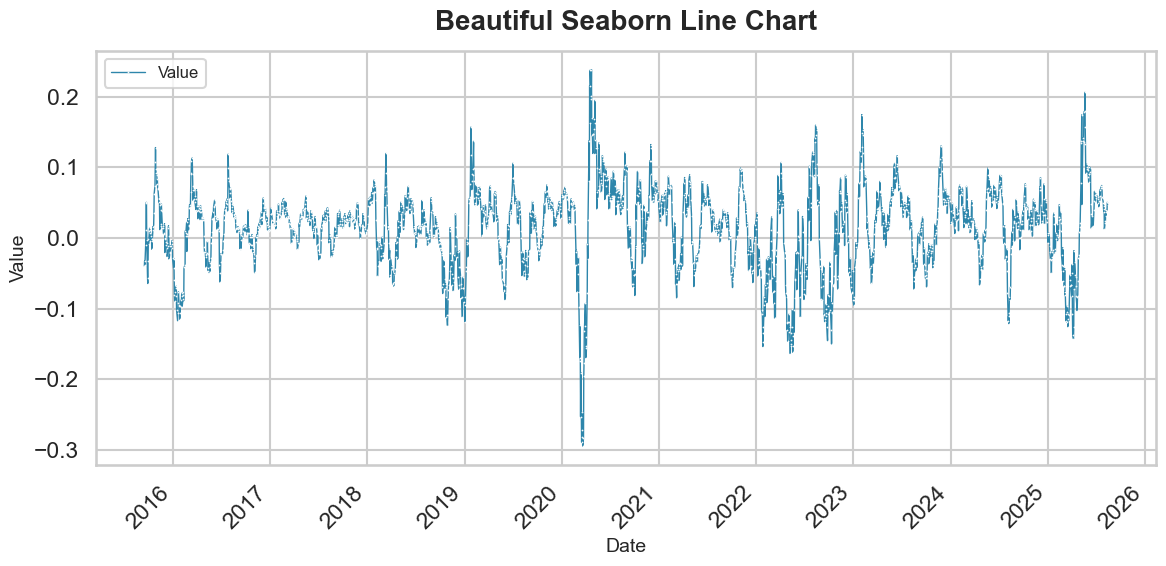

In [71]:
# Seaborn 스타일 설정
sns.set_theme(style="whitegrid")  # whitegrid / darkgrid / white / dark
sns.set_context("talk")  # talk / paper / notebook / poster

# 라인 차트
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df,
    x="date",
    y="monthly_return",
    linewidth=1,
    color="#2E86AB",  # 파란 계열
    marker="o",       # 데이터 포인트 표시
    markersize=0.5
)

# 타이틀 & 라벨
plt.title("Beautiful Seaborn Line Chart", fontsize=20, fontweight="bold", pad=15)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Value", fontsize=14)

# x축 날짜 포맷
plt.xticks(rotation=45, ha='right')

# 범례 (필요시)
plt.legend(["Value"], loc="upper left", fontsize=12)

# 여백 조정
plt.tight_layout()
plt.show()


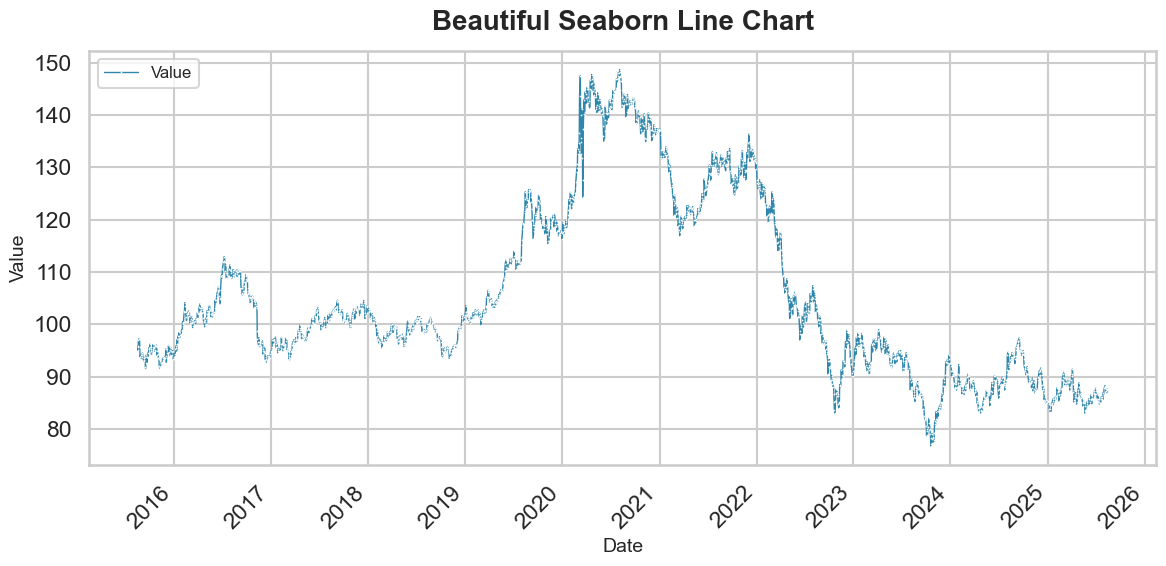

In [83]:
# Seaborn 스타일 설정
sns.set_theme(style="whitegrid")  # whitegrid / darkgrid / white / dark
sns.set_context("talk")  # talk / paper / notebook / poster

# 라인 차트
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df,
    x="date",
    y="미국장기채ETF",
    linewidth=1,
    color="#2E86AB",  # 파란 계열
    marker="o",       # 데이터 포인트 표시
    markersize=0.5
)

# 타이틀 & 라벨
plt.title("Beautiful Seaborn Line Chart", fontsize=20, fontweight="bold", pad=15)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Value", fontsize=14)

# x축 날짜 포맷
plt.xticks(rotation=45, ha='right')

# 범례 (필요시)
plt.legend(["Value"], loc="upper left", fontsize=12)

# 여백 조정
plt.tight_layout()
plt.show()


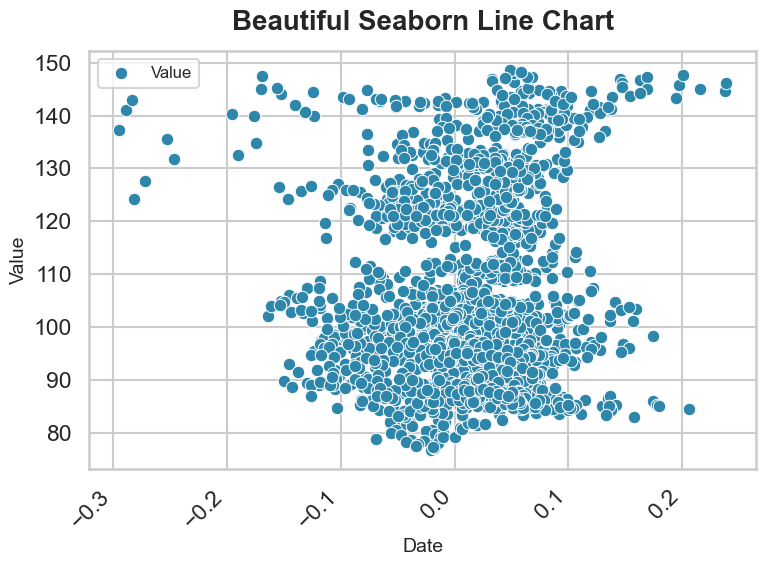

In [84]:
# Seaborn 스타일 설정
sns.set_theme(style="whitegrid")  # whitegrid / darkgrid / white / dark
sns.set_context("talk")  # talk / paper / notebook / poster

# 라인 차트
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="nasdaq_monthly",
    y="미국장기채ETF",
    color="#2E86AB",  # 파란 계열
    marker="o",       # 데이터 포인트 표시
)

# 타이틀 & 라벨
plt.title("Beautiful Seaborn Line Chart", fontsize=20, fontweight="bold", pad=15)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Value", fontsize=14)

# x축 날짜 포맷
plt.xticks(rotation=45, ha='right')

# 범례 (필요시)
plt.legend(["Value"], loc="upper left", fontsize=12)

# 여백 조정
plt.tight_layout()
plt.show()
